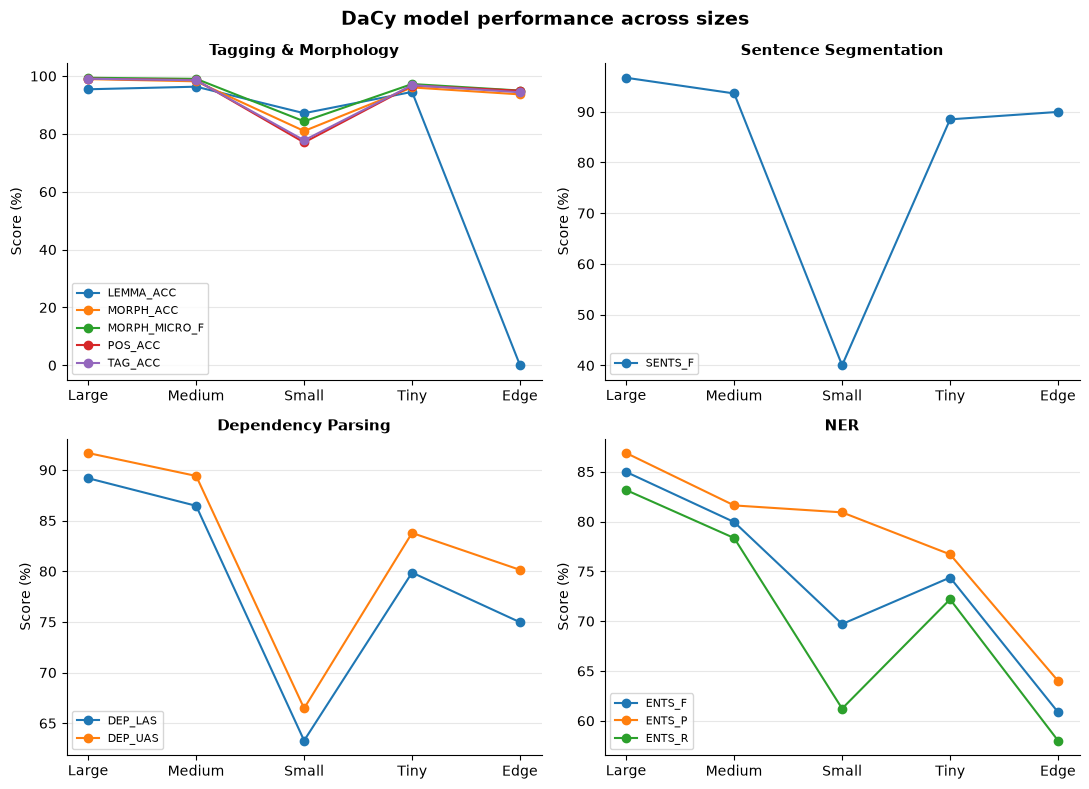

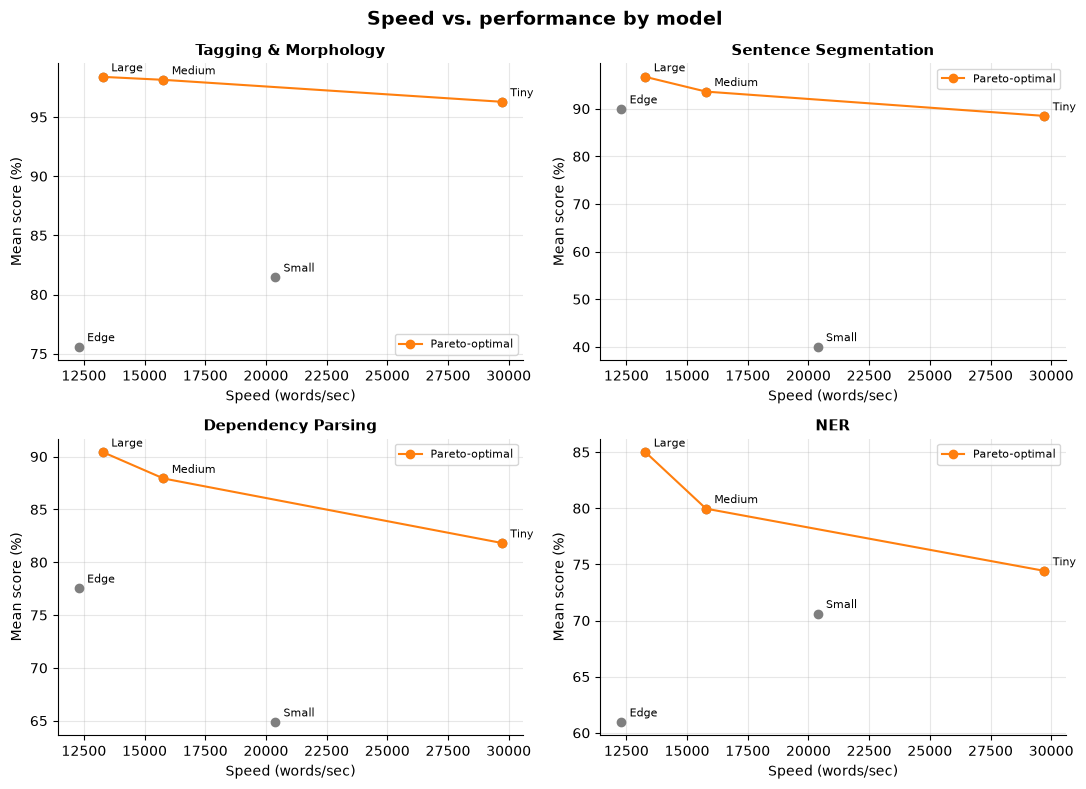

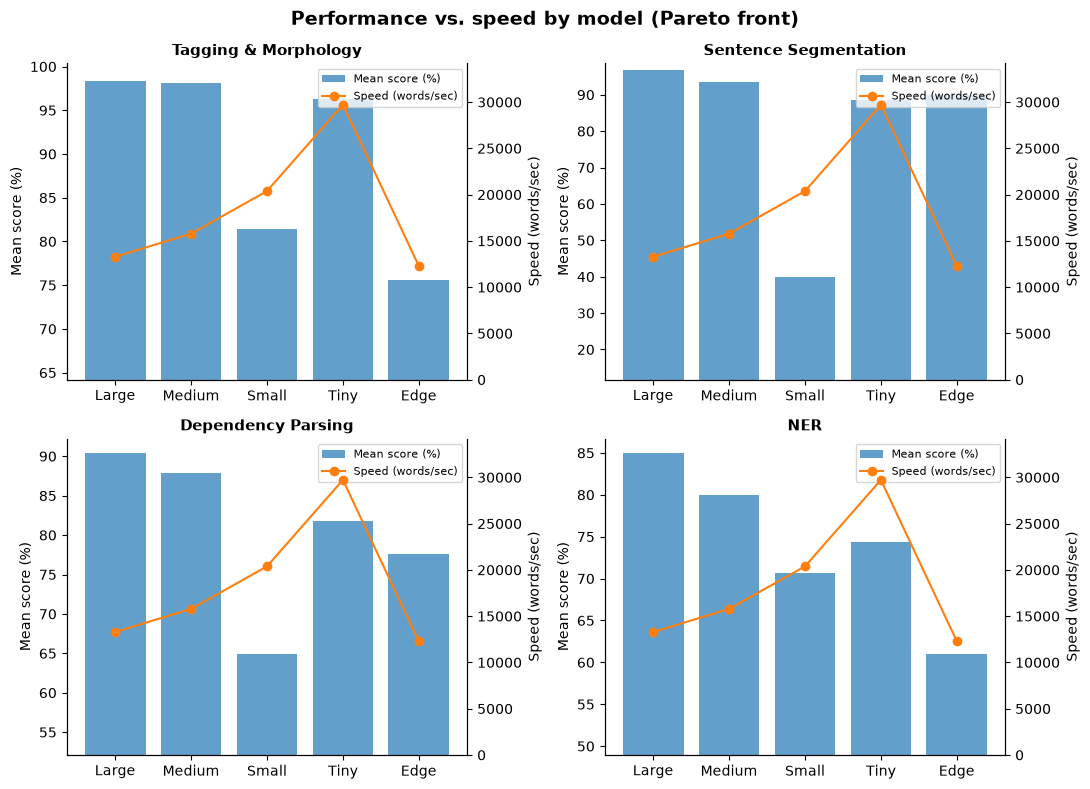

In [2]:
"""
Visualize DaCy model metrics from JSON files.
Edit MODELS below to swap which models are included/compared.
"""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Config: edit this to swap models in/out
METRICS_DIR = Path("/work/training_practice/ddt_dane_cdt_project/metrics")

# Order matters: this defines the x-axis order (Large -> Tiny)
MODELS = {
    "Large":  "dacy_large_trf.json",
    "Medium": "dacy_medium_trf.json",
    "Small":  "dacy_small_trf.json",
    "Tiny":   "dacy_tiny.json",
    "Edge": "dacy_edge.json"
}

# Metric groups: (family_label, [(json_key, display_label), ...])
METRIC_FAMILIES = [
    ("Tokenization", [("token_acc", "TOKEN_ACC"), ("token_f", "TOKEN_F")]),
    ("Tagging & Morphology", [
        ("tag_acc", "TAG_ACC"),
        ("pos_acc", "POS_ACC"),
        ("morph_acc", "MORPH_ACC"),
        ("morph_micro_f", "MORPH_MICRO_F"),
        ("lemma_acc", "LEMMA_ACC"),
    ]),
    ("Sentence Segmentation", [("sents_f", "SENTS_F")]),
    ("Dependency Parsing", [("dep_uas", "DEP_UAS"), ("dep_las", "DEP_LAS")]),
    ("NER", [("ents_p", "ENTS_P"), ("ents_r", "ENTS_R"), ("ents_f", "ENTS_F")]),
]


def load_metrics(models: dict, metrics_dir: Path) -> pd.DataFrame:
    """Return long-format df: model, family, metric, score (0-100, or NaN if missing)."""
    rows = []
    for model_name, filename in models.items():
        with open(metrics_dir / filename, encoding="utf-8") as f:
            data = json.load(f)
        for family, metrics in METRIC_FAMILIES:
            for key, label in metrics:
                value = data.get(key)  # None if missing (e.g. lemma_acc pre-retrain)
                rows.append({
                    "model": model_name,
                    "family": family,
                    "metric": label,
                    "score": value * 100 if value is not None else None,
                })
    df = pd.DataFrame(rows)
    df["model"] = pd.Categorical(df["model"], categories=list(models.keys()), ordered=True)
    return df

def is_constant(group: pd.DataFrame) -> bool:
    """True if a metric's score doesn't vary across models (ignoring missing values)."""
    return group["score"].dropna().nunique() <= 1

def plot_small_multiples(df: pd.DataFrame, savepath: str | None = None):
    families = [fam for fam, _ in METRIC_FAMILIES if fam in df["family"].unique()]
    # drop families where every metric is constant across all models
    families = [
        fam for fam in families
        if not df[df["family"] == fam].groupby("metric").apply(is_constant).all()
    ]
    n = len(families)
    # pick whichever of 2 or 3 columns leaves the fewest empty slots in the grid
    ncols = min((2, 3), key=lambda c: (-(-n // c) * c - n, -c))
    nrows = -(-n // ncols)  # ceil

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, family in zip(axes_flat, families):
        sub = df[df["family"] == family]
        for metric_label, group in sub.groupby("metric"):
            group = group.sort_values("model")
            ax.plot(group["model"], group["score"], marker="o", label=metric_label)

        ax.set_title(family, fontsize=11, fontweight="bold")
        ax.set_ylabel("Score (%)")
        ax.legend(fontsize=8, loc="lower left")
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle("DaCy model performance across sizes", fontsize=14, fontweight="bold")
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig

def get_families(df):
    """Metric families present in df, excluding ones where every metric is constant."""
    families = [fam for fam, _ in METRIC_FAMILIES if fam in df["family"].unique()]
    return [
        fam for fam in families
        if not df[df["family"] == fam].groupby("metric").apply(is_constant).all()
    ]

def load_speed(models, metrics_dir):
    """Return a model -> speed (words/sec, as reported in the JSON) series."""
    speeds = {}
    for model_name, filename in models.items():
        with open(metrics_dir / filename, encoding="utf-8") as f:
            data = json.load(f)
        speeds[model_name] = data["speed"]
    return pd.Series(speeds, name="speed")

def pareto_frontier(points):
    """Rows non-dominated when maximizing both speed and score, sorted by speed."""
    sorted_pts = points.sort_values("speed", ascending=False)
    frontier, best_score = [], -float("inf")
    for _, row in sorted_pts.iterrows():
        if row["score"] > best_score:
            frontier.append(row)
            best_score = row["score"]
    return pd.DataFrame(frontier).sort_values("speed")

def plot_pareto(df, speed, savepath=None):
    families = get_families(df)
    n = len(families)
    ncols = min((2, 3), key=lambda c: (-(-n // c) * c - n, -c))
    nrows = -(-n // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, family in zip(axes_flat, families):
        agg = df[df["family"] == family].groupby("model", observed=True)["score"].mean()
        points = pd.DataFrame({"speed": speed, "score": agg}).dropna()

        ax.scatter(points["speed"], points["score"], color="tab:gray", zorder=2, label="_nolegend_")
        for model, row in points.iterrows():
            ax.annotate(model, (row["speed"], row["score"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)

        frontier = pareto_frontier(points)
        ax.plot(frontier["speed"], frontier["score"], color="tab:orange",
                 marker="o", zorder=3, label="Pareto-optimal")

        ax.set_title(family, fontsize=11, fontweight="bold")
        ax.set_xlabel("Speed (words/sec)")
        ax.set_ylabel("Mean score (%)")
        ax.legend(fontsize=8, loc="best")
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle("Speed vs. performance by model", fontsize=14, fontweight="bold")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig

def plot_combo(df, speed, savepath=None):
    families = get_families(df)
    n = len(families)
    ncols = min((2, 3), key=lambda c: (-(-n // c) * c - n, -c))
    nrows = -(-n // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, family in zip(axes_flat, families):
        agg = df[df["family"] == family].groupby("model", observed=True)["score"].mean()
        agg = agg.reindex(MODELS.keys())  # keep Large -> Tiny order
        spd = speed.reindex(agg.index)

        bar = ax.bar(agg.index, agg.values, color="tab:blue", alpha=0.7, label="Mean score (%)")
        ax.set_ylabel("Mean score (%)")
        ax.set_ylim(agg.min() - (agg.max() - agg.min()) * 0.5, agg.max() * 1.02)

        ax2 = ax.twinx()
        line, = ax2.plot(spd.index, spd.values, color="tab:orange", marker="o", label="Speed (words/sec)")
        ax2.set_ylabel("Speed (words/sec)")
        ax2.set_ylim(0, spd.max() * 1.15)

        ax.set_title(family, fontsize=11, fontweight="bold")
        ax.spines[["top"]].set_visible(False)
        ax2.spines[["top"]].set_visible(False)
        ax.legend(handles=[bar, line], fontsize=8, loc="upper right")

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle("Performance vs. speed by model (Pareto front)", fontsize=14, fontweight="bold")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig

if __name__ == "__main__":
    df = load_metrics(MODELS, METRICS_DIR)
    speed = load_speed(MODELS, METRICS_DIR)

    plot_small_multiples(df, savepath="metrics_lines.png")
    plot_pareto(df, speed, savepath="metrics_pareto.png")
    plot_combo(df, speed, savepath="metrics_combo.png")
    plt.show()

In [ ]:
# CLAUDE
"""
Visualize DaCy model metrics from JSON files.

Three headline metrics (POS_ACC, ENTS_F, DEP_LAS) each get a bar plot and a
speed/performance pareto plot. Every metric, including the ones without plots,
appears in the exported markdown table.

Edit MODELS to swap models in/out; edit the `plot` flag in METRICS to change
which metrics get figures.
"""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

METRICS_DIR = Path("/work/training_practice/ddt_dane_cdt_project/metrics")
OUT_DIR = Path(".")

# Order defines the x-axis order everywhere.
MODELS = {
    "Large":  "dacy_large_trf.json",
    "Large (old)": "dacy_large_old.json",
    "Medium": "dacy_medium_trf.json",
    "Medium (old)": "dacy_medium_old.json",
    "Small":  "dacy_small_trf.json",
    "Small (old)": "dacy_small_old.json",
    "Tiny":   "dacy_tiny.json",
    "Edge":   "dacy_edge.json",
}

# Stamped onto the pareto plots. Speed is only comparable if every model was
# timed the same way, so state how.
HARDWARE_NOTE = "All models timed on identical hardware; see eval config."

# key, display label, task, gets_plot
# tag_acc is deliberately absent: identical to pos_acc for Danish. Verified at
# load time by check_tag_pos() rather than assumed.
METRICS = [
    ("token_acc",     "TOKEN_ACC",     "Tokenization",          False),
    ("token_f",       "TOKEN_F",       "Tokenization",          False),
    ("pos_acc",       "POS_ACC",       "Tagging & Morphology",  True),
    ("morph_acc",     "MORPH_ACC",     "Tagging & Morphology",  False),
    ("morph_micro_f", "MORPH_MICRO_F", "Tagging & Morphology",  False),
    ("lemma_acc",     "LEMMA_ACC",     "Tagging & Morphology",  False),
    ("sents_f",       "SENTS_F",       "Sentence Segmentation", False),
    ("dep_uas",       "DEP_UAS",       "Dependency Parsing",    False),
    ("dep_las",       "DEP_LAS",       "Dependency Parsing",    True),
    ("ents_p",        "ENTS_P",        "NER",                   False),
    ("ents_r",        "ENTS_R",        "NER",                   False),
    ("ents_f",        "ENTS_F",        "NER",                   True),
]

PLOTTED = [label for _, label, _, plot in METRICS if plot]


# --------------------------------------------------------------------------- #
# Loading
# --------------------------------------------------------------------------- #

def load_raw(models: dict, metrics_dir: Path) -> dict:
    """model name -> parsed JSON."""
    raw = {}
    for name, filename in models.items():
        with open(metrics_dir / filename, encoding="utf-8") as f:
            raw[name] = json.load(f)
    return raw


def build_scores(raw: dict) -> pd.DataFrame:
    """Wide df: rows = metric label, columns = model, values = score 0-100."""
    data = {
        label: {
            name: (d[key] * 100 if d.get(key) is not None else float("nan"))
            for name, d in raw.items()
        }
        for key, label, _, _ in METRICS
    }
    return pd.DataFrame(data).T.reindex(columns=list(raw))


def build_speed(raw: dict) -> pd.Series:
    """model -> speed in words/sec, as reported in the JSON."""
    return pd.Series({n: d.get("speed", float("nan")) for n, d in raw.items()})


# --------------------------------------------------------------------------- #
# Sanity checks — these warn, they never silently drop anything
# --------------------------------------------------------------------------- #

def check_tag_pos(raw: dict, tol: float = 1e-9) -> None:
    """tag_acc is dropped on the assumption it equals pos_acc. Verify that."""
    for name, d in raw.items():
        tag, pos = d.get("tag_acc"), d.get("pos_acc")
        if tag is None or pos is None:
            continue
        if abs(tag - pos) > tol:
            print(f"[warn] {name}: tag_acc ({tag:.4f}) != pos_acc ({pos:.4f}). "
                  "They are not interchangeable here — worth investigating.")


def report_gaps(scores: pd.DataFrame, speed: pd.Series) -> None:
    """Flag missing and suspiciously constant values."""
    for metric in scores.index:
        row = scores.loc[metric]
        for model in row.index[row.isna()]:
            print(f"[warn] missing {metric} for {model} — shown as '—', omitted from plots.")
        if row.notna().any() and row.dropna().nunique() == 1:
            print(f"[warn] {metric} is identical across all models — "
                  "check this is a real result, not a copied value.")
    for model in speed.index[speed.isna()]:
        print(f"[warn] missing speed for {model} — omitted from pareto plots.")


# --------------------------------------------------------------------------- #
# Plots
# --------------------------------------------------------------------------- #

def plot_bar(scores: pd.DataFrame, metric: str, savepath: Path | None = None):
    """Single metric, one bar per model, full 0-100 axis with value labels."""
    row = scores.loc[metric].dropna()

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(row.index, row.values, color="tab:blue")
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)

    ax.set_ylim(0, 100)
    ax.set_ylabel(f"{metric} (%)")
    ax.set_title(f"{metric} by model", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig


def pareto_frontier(points: pd.DataFrame) -> pd.DataFrame:
    """Rows non-dominated when maximizing both speed and score, sorted by speed."""
    ordered = points.sort_values("speed", ascending=False)
    keep, best = [], -float("inf")
    for name, row in ordered.iterrows():
        if row["score"] > best:
            keep.append(name)
            best = row["score"]
    return points.loc[keep].sort_values("speed")


def plot_pareto(scores: pd.DataFrame, speed: pd.Series, metric: str,
                savepath: Path | None = None, logx: bool = True):
    """Speed vs. one named metric. Zoomed y-axis: these are points, not bars."""
    points = pd.DataFrame({"speed": speed, "score": scores.loc[metric]}).dropna()
    frontier = pareto_frontier(points)
    n_dominated = len(points) - len(frontier)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(points["speed"], points["score"], color="tab:gray", zorder=2)
    ax.plot(frontier["speed"], frontier["score"], color="tab:orange",
            marker="o", zorder=3, label="Frontier")

    for name, row in points.iterrows():
        ax.annotate(name, (row["speed"], row["score"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

    if logx:
        ax.set_xscale("log")
    ax.set_xlabel("Speed (words/sec)" + (", log scale" if logx else ""))
    ax.set_ylabel(f"{metric} (%)")
    ax.margins(0.12)

    subtitle = ("no model is dominated" if n_dominated == 0
                else f"{n_dominated} of {len(points)} models dominated")
    ax.set_title(f"Speed vs. {metric}\n{subtitle}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="best")
    ax.spines[["top", "right"]].set_visible(False)

    fig.text(0.01, -0.02, HARDWARE_NOTE, fontsize=7, color="gray")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig


# --------------------------------------------------------------------------- #
# Table
# --------------------------------------------------------------------------- #

def to_markdown(scores: pd.DataFrame, speed: pd.Series,
                savepath: Path | None = None) -> str:
    """Every metric for every model, plus speed. Missing values render as '—'."""
    def fmt(v, spec):
        return format(v, spec) if pd.notna(v) else "—"

    header = ["Metric", *scores.columns]
    rows = [[m, *(fmt(v, ".2f") for v in scores.loc[m])] for m in scores.index]
    rows.append(["Speed (words/sec)", *(fmt(v, ",.0f") for v in speed[scores.columns])])

    widths = [max(len(r[i]) for r in [header, *rows]) for i in range(len(header))]
    align = ["<", *([">"] * (len(header) - 1))]

    def line(cells):
        return "| " + " | ".join(format(c, f"{a}{w}") for c, a, w
                                 in zip(cells, align, widths)) + " |"

    sep = "|" + "|".join(("-" * (w + 2)) if a == "<" else ("-" * (w + 1) + ":")
                         for a, w in zip(align, widths)) + "|"

    table = "\n".join([line(header), sep, *(line(r) for r in rows)])
    if savepath:
        savepath.write_text(table + "\n", encoding="utf-8")
    return table


# --------------------------------------------------------------------------- #

if __name__ == "__main__":
    raw = load_raw(MODELS, METRICS_DIR)
    scores = build_scores(raw)
    speed = build_speed(raw)

    check_tag_pos(raw)
    report_gaps(scores, speed)

    for metric in PLOTTED:
        plot_bar(scores, metric, savepath=OUT_DIR / f"bar_{metric.lower()}.png")
        plot_pareto(scores, speed, metric,
                    savepath=OUT_DIR / f"pareto_{metric.lower()}.png")

    print(to_markdown(scores, speed, savepath=OUT_DIR / "metrics_table.md"))
    plt.show()